# TP : Apprentissage Supervisé - Classification (exercice)
## Dataset : Spambase (détection de spam, OpenML)

**Algorithmes couverts :**

| Algo | Famille | Caractéristique |
|---|---|---|
| Régression Logistique | Linéaire | Rapide, interprétable |
| KNN | Instance-based | Simple, sensible à l'échelle |
| Decision Tree | Arbre | Interprétable, sujet à l'overfitting |
| Random Forest | Ensemble (bagging) | Robuste, peu de réglage |
| XGBoost | Ensemble (boosting) | Souvent le plus performant |

**Datamap (dictionnaire des données) :** 57 mesures extraites du texte de chaque email, regroupées en 3 familles.

| Famille de colonnes | Nombre | Description |
|---|---|---|
| `word_freq_*` | 48 | % d'occurrences d'un mot donné dans l'email (ex : `word_freq_free`, `word_freq_money`) |
| `char_freq_*` | 6 | % d'occurrences d'un caractère donné (`;`, `(`, `[`, `!`, `$`, `#`) |
| `capital_run_length_*` | 3 | Longueur des séquences de lettres majuscules (moyenne, la plus longue, totale) |

**Cible :** `class` : 0 = non-spam, 1 = spam.

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/02_supervise/tp_classification.ipynb` (même méthode, données différentes et plus volumineuses : 4601 emails contre 569 tumeurs).

---
## 0. Imports & configuration

In [ ]:
import ssl
import certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

---
## 1. Chargement & exploration

In [6]:
# Spambase : 4601 emails, 57 mesures (frequences de mots/caracteres, longueurs de sequences en majuscules)
# Chargement depuis OpenML (dataset public, aucune authentification requise)
spam = fetch_openml(name='spambase', version='active', as_frame=True, parser='auto')
df_raw = spam.frame.drop(columns=['class']).astype(float)
y = spam.frame['class'].astype(int).values
X = df_raw.values
feature_names = list(df_raw.columns)
class_names = ['non-spam', 'spam']

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [ ]:
df_raw.describe().round(2)

NameError: name 'class_names' is not defined

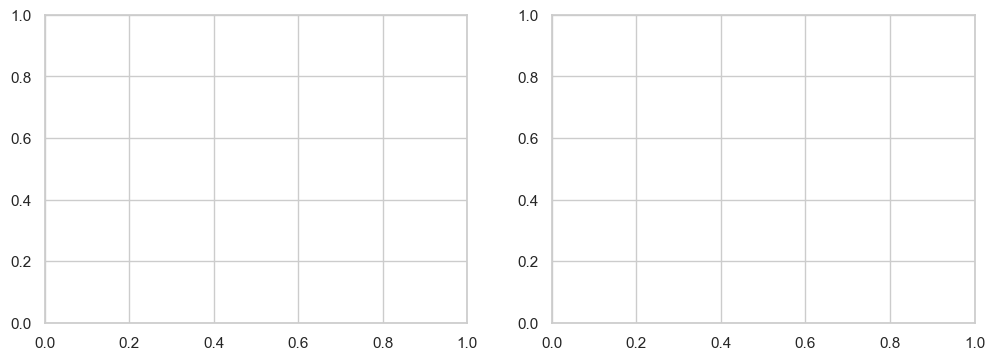

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_names, np.bincount(y), color=['steelblue', 'crimson'], edgecolor='k')
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'emails')

axes[1].hist(df_raw['word_freq_free'], bins=30, color='darkorange', edgecolor='k')
axes[1].set_title("Frequence du mot 'free'")
axes[1].set_xlabel('% d\'occurrences dans l\'email')

plt.tight_layout()
plt.show()


---
## 2. Prétraitement & split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons")
print(f"Train classes : {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Test  classes : {dict(zip(class_names, np.bincount(y_test)))}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

---
## 3. Régression Logistique

Modèle linéaire qui prédit la **probabilité** d'appartenir à une classe via la fonction sigmoïde.

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores_lr = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for C in C_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_lr.append(scores.mean())

best_C = C_values[np.argmax(cv_scores_lr)]

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, cv_scores_lr, 'bo-')
plt.axvline(best_C, color='green', linestyle='--', label=f'C optimal = {best_C}')
plt.xlabel('C (régularisation inverse)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('Régression Logistique : Optimisation de C')
plt.legend()
plt.tight_layout()
plt.show()

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
print(f"C optimal : {best_C} | ROC-AUC CV : {max(cv_scores_lr):.4f}")

---
## 4. KNN

Prédit la classe d'un point en regardant les **k voisins les plus proches**. Sensible à l'échelle → normalisation obligatoire.

In [ ]:
k_values = range(1, 31)
cv_scores_knn = []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_knn.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores_knn)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores_knn, 'rs-')
plt.axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('KNN : Optimisation de k')
plt.legend()
plt.tight_layout()
plt.show()

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn.fit(X_train, y_train)
print(f"k optimal : {best_k} | ROC-AUC CV : {max(cv_scores_knn):.4f}")

---
## 5. Decision Tree

Partitionne récursivement l'espace des features selon des seuils. Très interprétable mais tend à overfitter : régularisé via `max_depth`.

In [ ]:
depth_values = range(1, 21)
cv_scores_dt_train = []
cv_scores_dt = []

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_sc, y_train)
    cv_scores_dt_train.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    scores = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    cv_scores_dt.append(scores.mean())

best_depth = list(depth_values)[np.argmax(cv_scores_dt)]

plt.figure(figsize=(9, 4))
plt.plot(depth_values, cv_scores_dt_train, 'b--o', label='Accuracy train')
plt.plot(depth_values, cv_scores_dt, 'rs-', label='ROC-AUC CV')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Profondeur optimale = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.title('Decision Tree : Overfitting vs Profondeur')
plt.legend()
plt.tight_layout()
plt.show()

dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train_sc, y_train)
print(f"Profondeur optimale : {best_depth} | ROC-AUC CV : {max(cv_scores_dt):.4f}")

In [ ]:
# Visualisation de l'arbre (profondeur 3 pour la lisibilité)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_viz.fit(X_train_sc, y_train)

plt.figure(figsize=(20, 7))
plot_tree(dt_viz, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Decision Tree (max_depth=3) : visualisation')
plt.tight_layout()
plt.show()


---
## 6. Random Forest

Ensemble de **N arbres de décision** entraînés sur des sous-échantillons bootstrap et des sous-ensembles de features aléatoires.

In [ ]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=RANDOM_STATE)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres RF : {gs_rf.best_params_}")
print(f"ROC-AUC CV             : {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_

In [ ]:
importances_rf = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_rf.head(15).plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Random Forest : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 7. XGBoost

Boosting par gradient : construit les arbres **séquentiellement**, chaque arbre corrigeant les erreurs du précédent.

In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
}

xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"ROC-AUC CV              : {gs_xgb.best_score_:.4f}")

xgb_best = gs_xgb.best_estimator_

In [ ]:
importances_xgb = pd.Series(xgb_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_xgb.head(15).plot(kind='bar', color='darkorange', edgecolor='k')
plt.title('XGBoost : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 8. Évaluation & comparaison

### 8.1 Métriques sur le jeu de test

In [ ]:
models = {
    'Logistic Regression': pipe_lr,
    'KNN': pipe_knn,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

results = []
for name, model in models.items():
    if name in ['Logistic Regression', 'KNN']:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
df_results.round(4)

### 8.2 Courbes ROC

In [ ]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC : Comparaison des modèles')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 8.3 Matrices de confusion

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()


### 8.4 Rapport de classification du meilleur modèle

In [ ]:
best_model_name = df_results.iloc[0]['Modèle']
best_model = models[best_model_name]
X_eval = X_test if best_model_name in ['Logistic Regression', 'KNN'] else X_test_sc

print(f"Meilleur modèle : {best_model_name}\n")
print(classification_report(y_test, best_model.predict(X_eval), target_names=class_names))

---
## 9. Analyse de l'overfitting : courbes de validation

In [ ]:
n_range = [10, 50, 100, 200, 300]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(random_state=RANDOM_STATE),
    X_train_sc, y_train,
    param_name='n_estimators',
    param_range=n_range,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

plt.figure(figsize=(8, 4))
plt.plot(n_range, train_scores.mean(axis=1), 'b-o', label='Train')
plt.fill_between(n_range, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.1, color='b')
plt.plot(n_range, val_scores.mean(axis=1), 'r-s', label='Validation CV')
plt.fill_between(n_range, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='r')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.title('Courbe de validation : Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

---
## 10. Explicabilité avec SHAP

Un modèle boîte noire (Random Forest, XGBoost) est précis mais difficile à justifier auprès du métier. Les **valeurs de Shapley** (SHAP) attribuent à chaque variable sa contribution à une prédiction, sans changer le modèle :
$$\text{prédiction} = \text{valeur de base} + \sum_{i} \text{valeur de Shapley}(x_i)$$

On illustre la méthode sur XGBoost.

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test_sc, feature_names=feature_names)

**Lecture du graphique (summary plot) :** chaque point est un email du jeu de test. La position horizontale indique l'impact sur la prédiction (vers la droite : pousse vers "spam", vers la gauche : pousse vers "non-spam"), et la couleur la valeur de la feature (rouge = valeur élevée, bleu = valeur faible). Les variables sont triées par impact moyen absolu (importance globale).

In [ ]:
explanation = explainer(X_test_sc[:1])
shap.plots.waterfall(explanation[0])

print(f"Vraie classe : {class_names[y_test[0]]} | Prédite : {class_names[xgb_best.predict(X_test_sc[:1])[0]]}")

---
## 11. Choisir le modèle final : erreur, performance et explicabilité

Le modèle final ne se choisit pas seulement sur la métrique de performance : trois critères entrent en jeu :
1. **Minimiser l'erreur** (ici : 1 - accuracy)
2. **Maximiser la performance** (ici : ROC-AUC, robuste au déséquilibre de classes)
3. **Maximiser l'explicabilité** (nativement interprétable, ou via SHAP pour une boîte noire)

In [ ]:
explicabilite = {
    'Logistic Regression': 'Haute (coefficients directs)',
    'KNN': 'Faible (pas de règle ni de coefficient)',
    'Decision Tree': 'Très haute (règles lisibles)',
    'Random Forest': 'Moyenne (boîte noire, expliquée via SHAP)',
    'XGBoost': 'Moyenne (boîte noire, expliquée via SHAP)',
}

df_choix = df_results.copy()
df_choix['Erreur (1 - Accuracy)'] = 1 - df_choix['Accuracy']
df_choix['Explicabilité'] = df_choix['Modèle'].map(explicabilite)
df_choix = df_choix[['Modèle', 'Erreur (1 - Accuracy)', 'ROC-AUC', 'Explicabilité']]
df_choix.round(4)

In [ ]:
best_final_name = df_results.iloc[0]['Modèle']
best_final_model = models[best_final_name]

print(f"Modèle final retenu : {best_final_name}")
print(f"  Erreur (1 - Accuracy) : {1 - df_results.iloc[0]['Accuracy']:.4f}")
print(f"  ROC-AUC               : {df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"  Explicabilité         : {explicabilite[best_final_name]}")

---
## 12. Stocker le modèle final

In [ ]:
import joblib
import os

os.makedirs('modeles', exist_ok=True)
joblib.dump(best_final_model, 'modeles/best_model_classification.pkl')

print(f"Modèle sauvegardé : modeles/best_model_classification.pkl ({best_final_name})")

Si `best_final_model` est un `Pipeline` scikit-learn (normalisation + modèle, comme pour Logistic Regression ou KNN dans ce TP), un seul fichier suffit. Si le modèle retenu a été entraîné sur des données déjà standardisées à la main (comme Decision Tree, Random Forest ou XGBoost ici, via `X_train_sc`), il faut aussi sauvegarder le `scaler` séparément (`joblib.dump(scaler, ...)`).

---
## 13. Inférence simple, sans API

In [ ]:
nouvelles_donnees = pd.DataFrame(X_test[:10], columns=feature_names)

model_charge = joblib.load('modeles/best_model_classification.pkl')

if best_final_name in ['Logistic Regression', 'KNN']:
    predictions = model_charge.predict(nouvelles_donnees.values)
    probabilites = model_charge.predict_proba(nouvelles_donnees.values)[:, 1]
else:
    X_new_sc = scaler.transform(nouvelles_donnees.values)
    predictions = model_charge.predict(X_new_sc)
    probabilites = model_charge.predict_proba(X_new_sc)[:, 1]

nouvelles_donnees['prediction'] = [class_names[p] for p in predictions]
nouvelles_donnees['probabilite_spam'] = probabilites.round(4)
nouvelles_donnees.to_csv('predictions_classification.csv', index=False)

print(f"Prédictions sauvegardées : predictions_classification.csv ({len(nouvelles_donnees)} lignes)")
nouvelles_donnees[['prediction', 'probabilite_spam']]

---
## 14. Conclusion

| Critère | LogReg | KNN | Decision Tree | Random Forest | XGBoost |
|---|---|---|---|---|---|
| Interprétabilité | ★★★★ | ★★ | ★★★★★ | ★★ | ★★ |
| Performance typique | ★★★ | ★★★ | ★★★ | ★★★★ | ★★★★★ |
| Sensible à l'échelle | Oui | Oui | Non | Non | Non |
| Risque d'overfitting | Faible | Moyen | Élevé | Faible | Moyen (à régler) |

**À retenir :** sur un problème de détection de spam, le rappel (ne pas rater de spam) et la précision (ne pas bloquer un email légitime) ont un coût très différent : le choix du modèle final dépend du seuil de décision et du contexte métier.

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Quel C as-tu retenu pour la régression logistique, et comment as-tu arbitré entre les valeurs testées ?


C = 10, choisi par CV 5-fold stratifiée au ROC-AUC (0.9709), plateau à partir de C = 1

**Q2.** Quel k as-tu choisi pour KNN, sur quel critère ?

k = 12, même critère (AUC CV 0.9592), compromis biais/variance

**Q3.** Quelle profondeur maximale as-tu retenue pour l'arbre de décision ? As-tu observé du surapprentissage (écart train/test) pour les profondeurs plus grandes ?

6 ; oui surapprentissage net au-delà (train acc 0.93 → 0.99 pendant que l'AUC CV chute de 0.928 à ~0.90)

**Q4.** Quels hyperparamètres GridSearchCV a-t-il sélectionnés pour le Random Forest et pour XGBoost ?

RF max_depth=None, max_features='log2', n_estimators=200 ; XGB lr=0.1, depth=7, n=200, subsample=1.0

**Q5.** D'après ton tableau récapitulatif, quel modèle obtient les meilleures performances, et selon quelle métrique ? Pour un filtre anti-spam, pourquoi privilégier la précision ou le rappel selon le cas (coût d'un faux positif : un email légitime classé comme spam) ?

XGBoost en tête au ROC-AUC (0.9869) ; pour l'anti-spam on privilégie la précision car un faux positif (email légitime bloqué) coûte plus cher

**Q6.** Que montre la courbe de validation_curve que tu as tracée : à partir de quel réglage le modèle commence-t-il à surapprendre ?

train à 1.0 dès 10 arbres, validation qui monte puis plafonne vers 200 — le RF ne surapprend pas plus avec plus d'arbres

**Q7.** Sur le summary plot SHAP de XGBoost, quelles sont les 2-3 variables qui ont le plus d'impact sur la détection de spam ?

word_freq_george, char_freq_$, capital_run_length_total (+ mention de l'artefact george/hp du dataset)

**Q8.** Quel modèle final as-tu obtenu après arbitrage erreur/performance/explicabilité (section 11) ? Est-ce le même que le "meilleur" modèle de la section 8 ? Pourquoi ?

XGBoost, identique à la section 8, boîte noire compensée par SHAP

**Q9.** Sur les 10 nouvelles prédictions sauvegardées dans `predictions_classification.csv`, combien sont classées comme spam ?

5 spams sur 10